In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.linear_model import RANSACRegressor

import warnings
warnings.filterwarnings('ignore')

In [2]:
res = pd.read_excel('data_fujian.xlsx', usecols='B:L', skiprows=1).values

In [3]:
# 缺失值检测
nanvalue = np.argwhere(np.isnan(res))
if nanvalue.size == 0:
    print('No missing values')
else:
    rows_ = nanvalue.shape[0]
    rows = res.shape[0]
    print(f'Number of missing values: {rows_}, Rate of missing: {rows_/rows:.4f}')

No missing values


In [4]:
def filloutliers_movmedian(data, window=15):
    """使用移动中位数进行离群值裁剪"""
    result = data.copy()
    for col in range(data.shape[1]):
        series = pd.Series(data[:, col])
        # 计算移动中位数
        rolling_median = series.rolling(window=window, center=True, min_periods=1).median()
        # 计算移动MAD (median absolute deviation)
        rolling_mad = series.rolling(window=window, center=True, min_periods=1).apply(
            lambda x: np.median(np.abs(x - np.median(x)))
        )
        # 设定上下界 (使用3倍MAD)
        lower = rolling_median - 3 * rolling_mad
        upper = rolling_median + 3 * rolling_mad
        # 裁剪
        result[:, col] = np.clip(series, lower, upper)

    return result

res_new = filloutliers_movmedian(res, window=15)

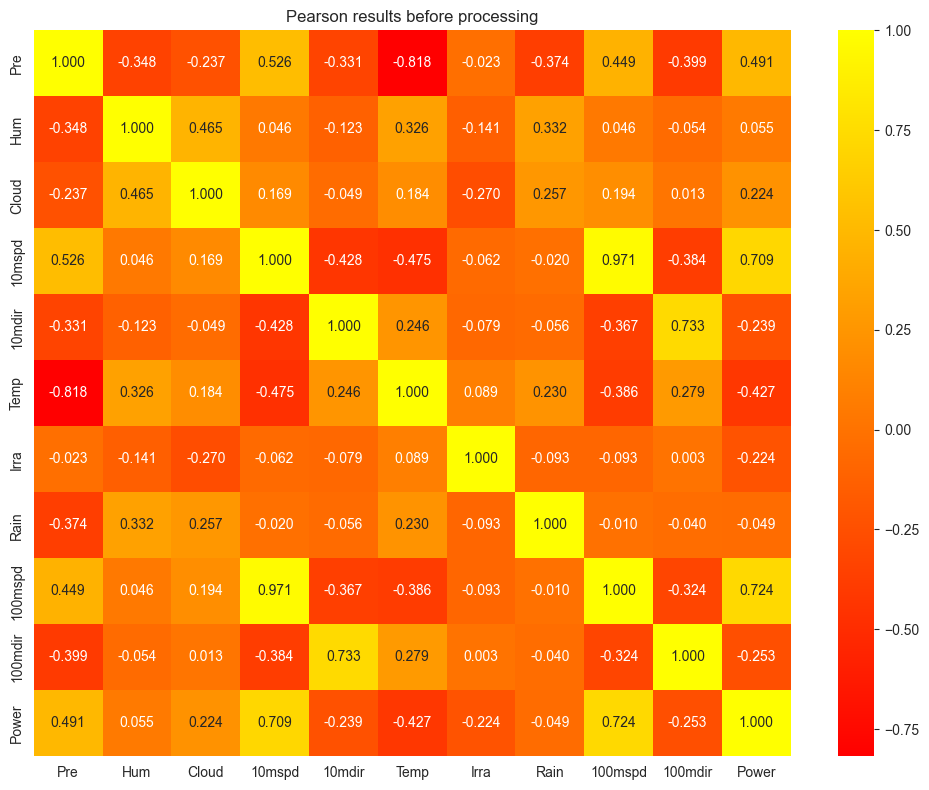

In [5]:
# 绘制处理前特征与标签相关性热力图
labels = ['Pre', 'Hum', 'Cloud', '10mspd', '10mdir', 'Temp', 'Irra', 'Rain', '100mspd', '100mdir', 'Power']

rho = np.corrcoef(res_new.T)

plt.figure(figsize=(10, 8))
sns.heatmap(rho, annot=True, fmt='.3f', xticklabels=labels, yticklabels=labels,
            cmap='autumn', cbar=True)
plt.title('Pearson results before processing', fontsize=12)
plt.tight_layout()
#plt.savefig('Pearson results before processing.png', dpi=400)
plt.show()

<Figure size 1000x600 with 0 Axes>

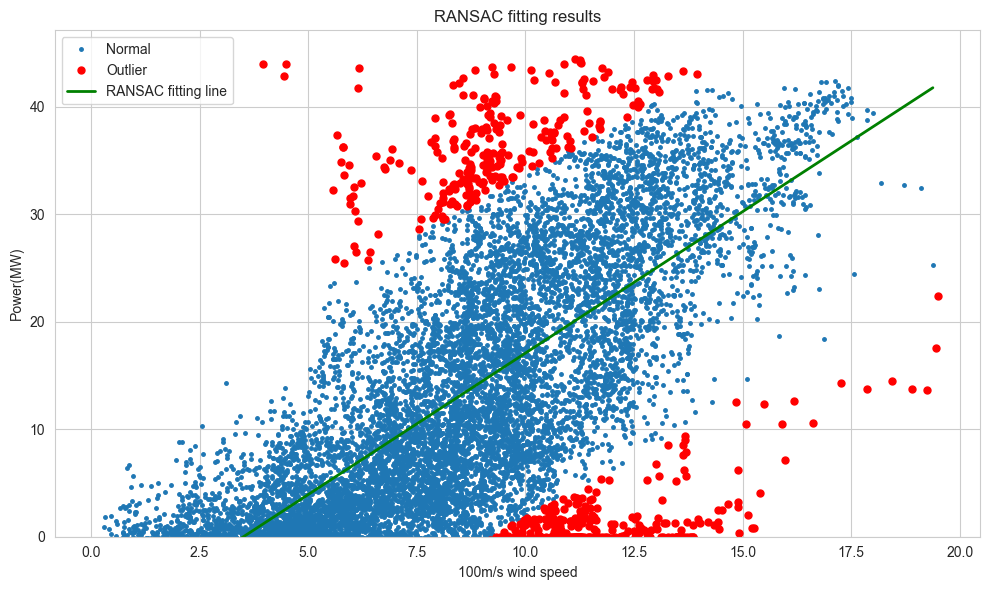

In [6]:
x = res_new[:, 8].reshape(-1, 1)  # 100mspd (第9列，索引8)
y = res_new[:, -1]  # Power (最后一列)
ransac = RANSACRegressor(min_samples=25,
    residual_threshold=16,
    random_state=42)
ransac.fit(x, y)
inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)

x_inliers = x[inlier_mask].flatten()  # 或 .ravel()
y_inliers = y[inlier_mask].flatten()
coefficients = np.polyfit(x_inliers, y_inliers, 1)  # 1次多项式，即直线
poly_func = np.poly1d(coefficients)

# 绘图
plt.figure(figsize=(10, 6))

# 绘制内点
#plt.scatter(x[inlier_mask], y[inlier_mask], label='Normal', alpha=0.6)

# 绘制外点
#plt.scatter(x[outlier_mask], y[outlier_mask], color='red', label='Outlier', alpha=0.6)

# 绘制RANSAC拟合线
#plt.plot(x_line, y_line, color='green', linewidth=2, label='RANSAC fitting line')

# 绘制RANSAC拟合结果
modelRANSAC = [ransac.estimator_.coef_[0], ransac.estimator_.intercept_]

# 绘制RANSAC拟合结果
plt.figure(figsize=(10, 6))
plt.plot(x[inlier_mask], y[inlier_mask], '.', label='Normal', markersize=5)
plt.plot(x[outlier_mask], y[outlier_mask], 'ro', label='Outlier', markersize=5)

# 绘制拟合线
x_line = np.linspace(x[inlier_mask].min(), x[inlier_mask].max(), 100)
y_line = ransac.predict(x_line.reshape(-1, 1))
plt.plot(x_line, y_line, 'g-', linewidth=2, label='RANSAC fitting line')


plt.title('RANSAC fitting results')
plt.xlabel('100m/s wind speed')
plt.ylabel('Power(MW)')
plt.ylim(bottom=0)  # 设置纵轴从0开始
plt.legend()
plt.tight_layout()
#plt.savefig("RANSAC fitting results.png", dpi=400)
plt.show()

In [7]:
def iso_forest(res):
    """
    使用孤立森林进行异常检测

    参数:
        res: numpy数组，输入数据

    返回:
        error_pos: 列表，每列对应的异常值索引
    """
    # 超参数设置
    np.random.seed(42)  # 固定随机种子
    contamination_fraction = 0.05  # 设置异常比例

    # 初始化结果数组
    n_cols = res.shape[1]
    tf_forest = np.zeros((res.shape[0], n_cols), dtype=bool)

    # 孤立森林进行检测
    for i in range(n_cols):
        # 准备数据：当前列和最后一列
        data = np.column_stack([res[:, i], res[:, -1]])

        # 创建孤立森林模型
        forest = IsolationForest(
            contamination=contamination_fraction,
            random_state=42,
            n_estimators=100
        )

        # 拟合并预测
        predictions = forest.fit_predict(data)

        # -1表示异常值，1表示正常值
        # 转换为布尔值：True表示异常
        tf_forest[:, i] = (predictions == -1)

    # 异常值位置
    error_pos = []
    for i in range(n_cols):
        error_indices = np.where(tf_forest[:, i])[0]
        error_pos.append(error_indices)

    return error_pos

In [8]:
T_linear = modelRANSAC[0] * res_new[:, 8] + modelRANSAC[1]
T_linear = np.maximum(T_linear, 0)  # 将负值设为0

residual_power = np.abs(res_new[:, -1] - T_linear)

# 孤立森林判断异常值
# 使用前9列特征 + 残差
features_for_isolation = np.column_stack([
    res_new[:, [0, 1, 2, 3, 4, 5, 6, 7, 9]],  # 前9列（跳过索引8）
    residual_power
])
error_pos2 = iso_forest(features_for_isolation)

# 替代异常值
for i in range(len(error_pos2)):
    if len(error_pos2[i]) > 0:
        res_new[error_pos2[i], -1] = T_linear[error_pos2[i]]

res_new[outlier_mask, -1] = T_linear[outlier_mask]

In [9]:
res_new

array([[1.02546381e+05, 9.79398000e+01, 1.00000000e+00, ...,
        1.20726000e+01, 1.52061000e+01, 3.36000000e+01],
       [1.02539680e+05, 9.75816000e+01, 1.00000000e+00, ...,
        1.19453000e+01, 1.49341000e+01, 3.28600000e+01],
       [1.02533916e+05, 9.62479000e+01, 1.00000000e+00, ...,
        1.18082000e+01, 1.46339000e+01, 3.52400000e+01],
       ...,
       [1.01305079e+05, 8.19826000e+01, 5.41550000e-01, ...,
        5.60810000e+00, 1.07602000e+01, 3.13000000e+00],
       [1.01307131e+05, 8.28310000e+01, 6.17610000e-01, ...,
        5.55500000e+00, 1.44152000e+01, 3.68000000e+00],
       [1.01309945e+05, 8.37218000e+01, 6.66110000e-01, ...,
        5.53150000e+00, 1.81353000e+01, 4.20000000e+00]])

In [9]:
pd.DataFrame(res_new, columns=labels).to_csv('res_new.csv', index=False)

In [11]:
import gc
gc.collect()

0